# LDA

## Полученные здесь лематизированные тексты, словарь, корпус, и обученная модель сохранены в файлах, которые используются в файле <span style='color: lightblue;'>gensim_LDA_2.ipynb</span>

## Загрузка данных -> return <font color='lightgreen'> <big>data</big></font>, type<font color='yellow'> <big>list/list</big></font>. 

Набор данных «20 групп новостей», содержащий тысячи новостных статей из различных разделов новостных сводок. Доступен в наборах данных Sklearn. 

In [62]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

In [63]:
newsgroups_train.data[:4]

["From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n",
 "From: guykuo@carson.u.washington.edu (Guy Kuo)\nSubject: SI Clock Poll - Final Call\nSummary: Final call for SI clock reports\nKeywords: SI,acceleration,clock,upgrade\nArticle-I.D.: shelley.1qvfo9INNc3s\nOrganization: University of Washington\nLines: 

In [64]:
type(newsgroups_train.data)

list

In [65]:
len(newsgroups_train.data)

11314

In [66]:
data = newsgroups_train.data

In [67]:
type(data)

list

## Импорт необходимых пакетов

In [68]:
import re
import numpy as np
import pandas as pd
from pprint import pprint
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt
import pickle # Для сохранения словаря, корпуса и модели

In [69]:
np.version.version

'1.26.4'

In [70]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaps\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [71]:
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

In [72]:
type(stop_words)

list

## Очистка текста перед лемматизацией -> return <font color='lightgreen'> <big>data_words_trigrams</big></font>, type<font color='yellow'> <big>list/list</big></font>. 

Функция Gensim <font color = 'lightgreen'>simple_preprocess()</font>:  -> return type<font color='yellow'> <big>(list)</big></font>
- приводит текст к нижнему регистру;
- удаляет небуквенные символы (например, пунктуацию);
- разбивает текст на токены (слова);
- исключает слишком короткие или длинные слова (по умолчанию слова длиной менее 2 символов и более 15 символов);  

In [73]:
# Преобразовываем каждое предложение в список слов
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
        # Ключевое слово yield используется для создания генератора. 
        # Вместо того чтобы возвращать сразу весь результат, 
        # генератор возвращает обработанные предложения по одному, 
        # позволяя экономить память при обработке больших объемов данных.
        

In [74]:
data_words = list(sent_to_words(data))

In [75]:
type(data_words)

list

In [76]:
data_words[0]

['from',
 'lerxst',
 'wam',
 'umd',
 'edu',
 'where',
 'my',
 'thing',
 'subject',
 'what',
 'car',
 'is',
 'this',
 'nntp',
 'posting',
 'host',
 'rac',
 'wam',
 'umd',
 'edu',
 'organization',
 'university',
 'of',
 'maryland',
 'college',
 'park',
 'lines',
 'was',
 'wondering',
 'if',
 'anyone',
 'out',
 'there',
 'could',
 'enlighten',
 'me',
 'on',
 'this',
 'car',
 'saw',
 'the',
 'other',
 'day',
 'it',
 'was',
 'door',
 'sports',
 'car',
 'looked',
 'to',
 'be',
 'from',
 'the',
 'late',
 'early',
 'it',
 'was',
 'called',
 'bricklin',
 'the',
 'doors',
 'were',
 'really',
 'small',
 'in',
 'addition',
 'the',
 'front',
 'bumper',
 'was',
 'separate',
 'from',
 'the',
 'rest',
 'of',
 'the',
 'body',
 'this',
 'is',
 'all',
 'know',
 'if',
 'anyone',
 'can',
 'tellme',
 'model',
 'name',
 'engine',
 'specs',
 'years',
 'of',
 'production',
 'where',
 'this',
 'car',
 'is',
 'made',
 'history',
 'or',
 'whatever',
 'info',
 'you',
 'have',
 'on',
 'this',
 'funky',
 'looking',


### Построение моделей биграмм и триграмм. 

Функция <font color='lightgreen'>gensim.models.Phrases</font> -> return type<font color='yellow'> <big>  (объект класса Phrases)</big></font>.  
Этот объект представляет собой модель, которая обучена на предоставленных данных и может быть использована для автоматического обнаружения фраз (би- и триграмм) в текстах.

In [77]:
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)

# min_count (5) - указывает минимальное количество появления комбинации слов для того, чтобы она считалась потенциальной фразой.
# Если два слова вместе встречаются реже min_count, то они не будут рассматриваться как фраза.

# threshold (10) - порог для определения, насколько сильна связь между словами. Чем выше значение, тем более строгий критерий используется для объединения слов в фразы.
# Формула основана на мерах статистической значимости. Если слова вместе появляются значительно чаще, чем ожидалось случайно, они будут объединены.
# Если частота совместного появления превышает заданный порог (threshold) 
# и количество таких случаев больше или равно min_count, 
# то слова объединяются в одну фразу через подчеркивание (например, 'new' и 'york' превращаются в 'new_york').

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)
# Зачем еще раз включать phrases?
# phrasesсоздаёт более оптимизированный и лёгкий объект для использования биграммной модели. 

### Переработка - стоп-слова, биграммы и триграммы.

In [78]:
def remove_stopwords(texts):
    return [[word for word in doc if word not in stop_words] for doc in texts]
# как работают такого рода вложенные циклы
# (1) - выполняется внешний цикл: [[...]for doc in texts] - поскольку texts это data_words (список списков), то в doc попадает поочередно каждый вложенный список
# (2) - выполняется внутренний цикл: [word for word in doc if word not in stop_words] - обрабатывает каждое слово word в документе doc
# doc - это очередной вложенный список, проверяя, входит ли word в список стоп-слов stop_words.
# Если слово не является стоп-словом , оно добавляется в результирующий список.
# И еще. Внешний цикл передает doc во внутренний, там он перебирается через word, и оно возвращается в doc.

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

# Почему здесь bigram_mod[doc] квадратные скобки?
# bigram_mod является объектом класса gensim.models.phrases.Phraser. 
# Этот класс реализует метод __getitem__, который позволяет применять модель биграмм к текстам, 
# используя синтаксис квадратных скобок. 

# Когда пишется bigram_mod[doc], 
# это равнозначно вызову метода bigram_mod.__getitem__(doc).

# Метод же __getitem__ выполняет следующие действия:

# Принимает на вход последовательность слов (doc).
# Преобразует её, объединяя пары слов, которые были обучены как биграммы в модели bigram.
# Возвращает новую последовательность doc с учётом найденных биграмм.

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]
# Аналогично

In [79]:
data_words_nostops = remove_stopwords(data_words)

In [80]:
len(data_words_nostops[0])

65

In [81]:
data_words_bigrams = make_bigrams(data_words_nostops)

In [82]:
data_words_trigrams = make_bigrams(data_words_bigrams)

In [83]:
print(data_words[0])
print(len(data_words[0]))
print(data_words_nostops[0])
print(len(data_words_nostops[0]))
print(data_words_bigrams[0])
print(len(data_words_bigrams[0]))
print(data_words_trigrams[0])
print(len(data_words_trigrams[0]))

['from', 'lerxst', 'wam', 'umd', 'edu', 'where', 'my', 'thing', 'subject', 'what', 'car', 'is', 'this', 'nntp', 'posting', 'host', 'rac', 'wam', 'umd', 'edu', 'organization', 'university', 'of', 'maryland', 'college', 'park', 'lines', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'saw', 'the', 'other', 'day', 'it', 'was', 'door', 'sports', 'car', 'looked', 'to', 'be', 'from', 'the', 'late', 'early', 'it', 'was', 'called', 'bricklin', 'the', 'doors', 'were', 'really', 'small', 'in', 'addition', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', 'this', 'is', 'all', 'know', 'if', 'anyone', 'can', 'tellme', 'model', 'name', 'engine', 'specs', 'years', 'of', 'production', 'where', 'this', 'car', 'is', 'made', 'history', 'or', 'whatever', 'info', 'you', 'have', 'on', 'this', 'funky', 'looking', 'car', 'please', 'mail', 'thanks', 'il', 'brought', 'to', 'you', 'by', 'your', 'neighborhood', 'lerxst']
1

In [84]:
print(data_words_trigrams[:3])


[['lerxst', 'wam_umd', 'thing', 'car', 'nntp_posting', 'host', 'rac_wam', 'umd', 'organization', 'university', 'maryland_college', 'park', 'lines', 'wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'doors', 'really', 'small', 'addition', 'front_bumper', 'separate', 'rest', 'body', 'know', 'anyone', 'tellme', 'model', 'name', 'engine', 'specs', 'years', 'production', 'car', 'made', 'history', 'whatever', 'info', 'funky', 'looking', 'car', 'please', 'mail', 'thanks', 'il', 'brought', 'neighborhood', 'lerxst'], ['guykuo_carson', 'washington', 'guy_kuo', 'si', 'clock', 'poll', 'final', 'call', 'summary', 'final', 'call', 'si', 'clock', 'reports', 'keywords', 'si', 'acceleration', 'clock', 'upgrade', 'article', 'shelley', 'qvfo', 'innc', 'organization', 'university', 'washington', 'lines', 'nntp_posting', 'host', 'carson_washington', 'fair', 'number', 'brave', 'souls', 'upgraded', 'si', 'clock', 'oscil

In [85]:
type(data_words_trigrams)

list

## Лемматизация   -> return <font color='lightgreen'> <big>lemmatized_txt</big></font>, type<font color='yellow'> <big>list/list</big></font>.  
### -> save <font color='orange'> <big>'lemmatized_txt.csv'</big></font> 

In [119]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

In [87]:
lemmatizer = WordNetLemmatizer()

In [88]:
nltk.download('averaged_perceptron_tagng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\shaps\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [89]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shaps\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [90]:
# Функция для определения части речи
def get_wordnet_pos(tag):
    tag_dict = {
        'J': wordnet.ADJ,  # прилагательное
        'N': wordnet.NOUN,  # существительное
        'V': wordnet.VERB,  # глагол
        'R': wordnet.ADV   # наречие
    }
    return tag_dict.get(tag[0].upper(), wordnet.NOUN)  # если POS неизвестен, берется существительное


In [91]:
lemmatized_txt = []
for tokens in data_words_trigrams:
        pos_tags = pos_tag(tokens)
        # print(pos_tags)
        lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
        # print(pos_tags)
        lemmatized_txt.append(lemmatized_words)

In [ ]:
lemmatized_txt[:2]

In [93]:
type(lemmatized_txt)

list

In [118]:
# Сохранение лемматизированного текста
import csv

with open('lemmatized_txt.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    for word in lemmatized_txt:
        writer.writerow([word])

## Построение словаря и корпуса для тематической модели  

### -> <u>return:</u> <big>dictionary</big> - <font color='lightgreen'> <big>id2word</big></font>, type - <font color='yellow'><big>gensim.corpora.dictionary.Dictionary</big></font> (if  <font color='lightgreen'> <big>id2word.token2id</big></font>, type - <font color='yellow'><big>dict</big></font>) <big>corpus</big> - <font color='lightgreen'> <big>corpus</big></font>, type<font color='yellow'> <big>list</big></font>.  
### -> <u>save:</u> dictionary - <font color='orange'><big>'dictionary.dict'</font> corpus - <font color='orange'> <big>'corpus.pkl'</font> 

#### Построение и сохранения словаря

In [94]:
id2word = corpora.Dictionary(lemmatized_txt)

In [ ]:
pprint(id2word.token2id)

In [105]:
print(type(id2word.token2id))

<class 'dict'>


In [106]:
print(len(id2word.token2id))

89628


In [107]:
print(id2word.token2id['addition'])


0


In [108]:
# Сохранение словаря
id2word.save('dictionary.dict')

#### Построение корпуса (мешка слов)

In [40]:
corpus = [id2word.doc2bow(text) for text in lemmatized_txt]

In [122]:
print(type(corpus))
print(corpus[0])

<class 'list'>
[(0, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 5), (7, 1), (8, 1), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 2), (22, 1), (23, 2), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1)]


In [109]:
# Сохранение корпуса
with open('corpus.pkl', 'wb') as f:
    pickle.dump(corpus, f)

## Построение тематической модели LDA -> return: <font color='lightgreen'>lda_model</font>

In [43]:
from gensim.models import LdaModel

In [44]:
lda_model = gensim.models.ldamodel.LdaModel(
   corpus=corpus, id2word=id2word, num_topics=20, random_state=100, 
   update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True
)

In [ ]:
pprint(lda_model.print_topics())

In [ ]:
# Какие темы мы получили
# Названий нет, в каждой теме набор слов, с вероятностями их встретить в данной теме
topics=lda_model.show_topics(num_topics=20, num_words=10,formatted=False)
print(type(topics)) # class - list
print(len(topics))

print(topics[1]) # конкретная тема (номер темы, слова, вероятности)
print(topics[1][1][:3]) # в конкретной теме только слова (выборочные - [:3])
# topics

<class 'list'>
20
(1, [('god', 0.027810313), ('people', 0.015184986), ('believe', 0.014836092), ('evidence', 0.01455069), ('reason', 0.013228232), ('say', 0.013099348), ('christian', 0.010463372), ('claim', 0.010083543), ('one', 0.009199816), ('may', 0.009148504)])
[('god', 0.027810313), ('people', 0.015184986), ('believe', 0.014836092)]


In [ ]:
topics_words = [(tp[0], [wd[0] for wd in tp[1]]) for tp in topics]
#Below Code Prints Only Words
for topic, words in topics_words:
    print("topic_{}: ".format(topic)+" ".join(words))

## Оценка сложности модели -> <font color='lightgreen'>lda_model.log_perplexity(corpus)</font>

Чем ниже оценка, тем лучше модель. 

In [ ]:
print('\nPerplexity: ', lda_model.log_perplexity(corpus))


Perplexity:  -15.301155278953084


## Оценка Когерентности вычислений -> <font color='lightgreen'>CoherenceModel(...)</font>

In [ ]:
coherence_model_lda = CoherenceModel(
 model=lda_model, texts=lemmatized_txt, dictionary=id2word, coherence='c_v'
)
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  0.5332167617816481


## Визуализация тем-ключевые слова -> <font color='lightgreen'>pyLDAvis.gensim.prepare(...)</font>

Для изучения созданных тем и связанных с ними ключевых слов можно использовать пакет pyLDAvis

Как будет видно ниже на графике, пузырьки слева представляют собой темы. Чем больше пузырёк, тем более распространена эта тема. Модель тем лучше, чем больше в ней непересекающихся пузырьков, разбросанных по всей диаграмме.

In [ ]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.394415 -0.150310       1        1  29.015088
7     -0.367315  0.026443       2        1  25.238260
1     -0.347519 -0.144592       3        1  11.488514
2     -0.272356  0.272488       4        1  11.297074
5      0.023934  0.119934       5        1   5.586597
0     -0.027529 -0.011917       6        1   2.761129
4      0.039848  0.017512       7        1   1.973644
10     0.061374  0.055258       8        1   1.857917
15     0.009722  0.111686       9        1   1.732524
16     0.040567 -0.123423      10        1   1.487811
12     0.061569  0.140260      11        1   1.253371
6      0.082547 -0.099987      12        1   1.199525
17     0.106848 -0.013430      13        1   1.123119
14     0.122471 -0.024094      14        1   0.918625
8      0.138858 -0.017831      15        1   0.839541
19     0.108535 -0.009744      16        1   0.739784
13     0.133511 -0.026309      17        1   0.648823
11     0.124528 -0.070117      18        1   0.616475
18     0.173867 -0.026209      19        1   0.164471
9      0.180955 -0.025615      20        1   0.057708, topic_info=               Term          Freq         Total Category  logprob  loglift
6428             ax  59947.000000  59947.000000  Default  30.0000  30.0000
22             line  19789.000000  19789.000000  Default  29.0000  29.0000
223             com  19631.000000  19631.000000  Default  28.0000  28.0000
31     organization  18150.000000  18150.000000  Default  27.0000  27.0000
2789            max   5039.000000   5039.000000  Default  26.0000  26.0000
...             ...           ...           ...      ...      ...      ...
8068          cache      0.010654      1.346853  Topic20 -11.4975   2.6179
5532       cso_uiuc      0.010654      1.346847  Topic20 -11.4975   2.6179
6811             mc      0.010654      1.347003  Topic20 -11.4975   2.6178
9419          print      0.010654      1.346885  Topic20 -11.4975   2.6179
14143            ay      0.010654      1.346869  Topic20 -11.4975   2.6179

[881 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
1199     17  0.995807            ab
1869      3  0.999209        accept
4404     11  0.996223  access_digex
2085      1  0.005173           act
2085      3  0.855195           act
...     ...       ...           ...
2613     13  0.992979          yale
51        1  0.758605          year
51        6  0.241152          year
1515     19  0.953472        yellow
2205     18  0.943454      zbib_bnr

[1135 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 8, 2, 3, 6, 1, 5, 11, 16, 17, 13, 7, 18, 15, 9, 20, 14, 12, 19, 10])

## Finding Optimal Number of Topics for LDA -> <font color='lightgreen'>model_list</font> type <font color='yellow'>list/list</font>

In [51]:
def coherence_values_computation(dictionary, corpus, texts, limit, start, step):
   coherence_values = []
   model_list = []
   for num_topics in range(start, limit, step):
      lda_model = gensim.models.ldamodel.LdaModel(
         corpus=corpus, id2word=dictionary, num_topics=num_topics, random_state=100, 
         update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True
         )
      pprint(len(lda_model.show_topics(formatted=False)))
      model_list.append(lda_model)
      coherencemodel = CoherenceModel(
      model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v'
      )
      coherence_values.append(coherencemodel.get_coherence())
   return model_list, coherence_values

In [ ]:
model_list, coherence_values = coherence_values_computation (
   dictionary=id2word, corpus=corpus, texts=lemmatized_txt, 
   start=25, limit=42, step=8
)

10
10
10


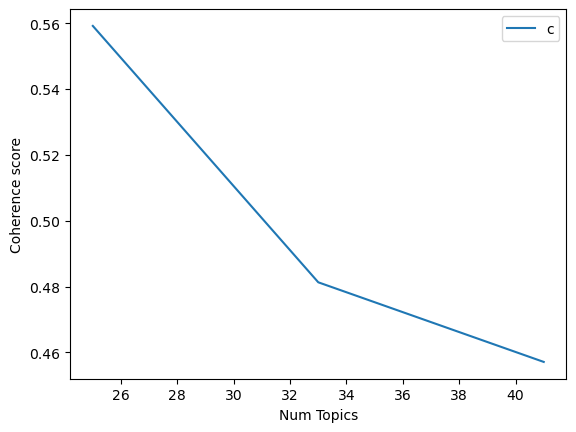

In [ ]:
start=25; limit=42; step=8;
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [54]:
pprint(len(model_list))

3


In [ ]:
for i in range(0, 3, 1):
    topics_1=model_list[i].show_topics(num_topics=55, num_words=10,formatted=False)
    # topics_1 - class list
    print(len(topics_1))
    print(topics_1) # конкретная тема (номер темы, слова, вероятности)
    print("__________________________________") 
# topics

25
[(0, [('hp', 0.052702747), ('de', 0.046150714), ('md', 0.04065506), ('newsreader_tin', 0.038019136), ('la', 0.03349798), ('version_pl', 0.029823983), ('dave', 0.026527468), ('sc', 0.02132478), ('mot', 0.018256221), ('caltech', 0.017754922)]), (1, [('god', 0.1810337), ('jesus', 0.04659703), ('faith', 0.046115205), ('bible', 0.038463548), ('church', 0.02732759), ('master', 0.022686414), ('die', 0.021744074), ('christ', 0.01797672), ('love', 0.016911287), ('hell', 0.016577147)]), (2, [('program', 0.049661346), ('file', 0.04572021), ('entry', 0.020101527), ('application', 0.016551409), ('disk', 0.0158722), ('source', 0.014838546), ('version', 0.014398135), ('display', 0.014338294), ('server', 0.014295232), ('code', 0.013490109)]), (3, [('gun', 0.073457025), ('internet', 0.047631085), ('wire', 0.032053243), ('slow', 0.029347463), ('device', 0.024891572), ('license', 0.02131716), ('factory', 0.020755367), ('notice', 0.020618329), ('internal', 0.019361714), ('ohio_state', 0.017880244)]), (

### Оцениваем в-ну когерентности вычислений

In [56]:
coherence_values

[0.5591500469255013, 0.48127620127128695, 0.4570939718317737]

## Определяем лучшую модель -> return <font color='lightgreen'>optimal_model</font>, к-во тем - 25.  
### -> <u>save:</u> <font color='orange'>'lda_model.model'</font>

In [57]:
optimal_model = model_list[0]
topics_optimal=optimal_model.show_topics(num_topics=25, num_words=10,formatted=False)
type(topics_optimal)

In [ ]:
topics_optimal

In [124]:
# Сохранение модели
optimal_model.save('lda_model.model')

### Example

In [59]:
topics_optimal[0]

(0,
 [('hp', 0.052702747),
  ('de', 0.046150714),
  ('md', 0.04065506),
  ('newsreader_tin', 0.038019136),
  ('la', 0.03349798),
  ('version_pl', 0.029823983),
  ('dave', 0.026527468),
  ('sc', 0.02132478),
  ('mot', 0.018256221),
  ('caltech', 0.017754922)])

In [60]:
tp_example = topics_optimal[0]
tp_example[1][0][0]

'hp'

### Смотрим темы

Выплняется внешний цикл, в котором перебираются элементы списка topics_optimal.  
tp содержит (кортеж) из 2 элементов: № топика и список из кортежей - [(слово, вероятность)]:  
(0, [('hp', 0.052702747),('de', 0.046150714), ... , ('caltech', 0.017754922)])  
Во внутренней процедуре из каждого значения tp берется нулевой элемент tp[0],  
в котором № топика, и итерируется второй элемент tp[1] ->  wd.  В wd поочередно появляются кортежи  
('hp', 0.052702747) ('de', 0.046150714) ... ('caltech', 0.017754922)  
из которых берутся нулевые элементы wd[0]: 'hp', 'de', ... , 'caltech'  

In [101]:
topics_words = [(tp[0], [wd[0] for wd in tp[1]]) for tp in topics_optimal]
print(topics_words)

[(0, ['hp', 'de', 'md', 'newsreader_tin', 'la', 'version_pl', 'dave', 'sc', 'mot', 'caltech']), (1, ['god', 'jesus', 'faith', 'bible', 'church', 'master', 'die', 'christ', 'love', 'hell']), (2, ['program', 'file', 'entry', 'application', 'disk', 'source', 'version', 'display', 'server', 'code']), (3, ['gun', 'internet', 'wire', 'slow', 'device', 'license', 'factory', 'notice', 'internal', 'ohio_state']), (4, ['may', 'reason', 'evidence', 'one', 'question', 'believe', 'christian', 'many', 'claim', 'people']), (5, ['team', 'game', 'win', 'play', 'st', 'year', 'player', 'pa', 'pin', 'em']), (6, ['send', 'list', 'sale', 'address', 'mail', 'include', 'book', 'copy', 'information', 'graphic']), (7, ['com', 'system', 'use', 'need', 'problem', 'new', 'work', 'also', 'get', 'computer']), (8, ['israel', 'israeli', 'jew', 'jewish', 'arab', 'tim', 'columbia', 'occupy', 'peace', 'withdraw']), (9, ['window', 'monitor', 'windows', 'character', 'normal', 'font', 'excuse', 'do', 'shell', 'ncsu']), (10,

In [ ]:
for topic, words in topics_words:
    print("topic_{}: ".format(topic)+" ".join(words))


## Поиск доминирующих тем в документах (<font color='lightgreen'>optimal_model</font>)

Определение номера темы, которая имеет наибольший процентный вклад в конкретный документ.

### Пояснения к основной процедуре

In [64]:
# Основная процедура
for i, row in enumerate(optimal_model[corpus]):
   row = sorted(row[0], key=lambda x: (x[1]), reverse=True)
# row содержит № тем и отсортированные вероятности принадлежности документа к данной теме 

Процедура цикла.
<font color='lightgreen'>for i, row in enumerate(optimal_model[corpus])</font>  

здесь <font color='lightgreen'>optimal_model[corpus]</font> представляет собой список вероятностей тем для каждого документа в корпусе.  
Каждая строка <big><u>(row)</u></big> соответствует одному документу и  
<u>содержит список пар вида (topic_id, probability)</u>, где:  
topic_id — номер темы.  
probability — вероятность того, что документ относится к этой теме.  

Функция <font color='lightgreen'>enumerate</font> используется для перебора итерируемого объекта (например, списка, кортежа или строки), одновременно предоставляя индекс каждого элемента и сам элемент.  
Соответственно, в <big><u>i</u></big> находится <u>индекс текущего документа в корпусе</u>.


Процедура сортировки.
<font color='lightgreen'>row = sorted(row[0], key=lambda x: (x[1]), reverse=True)</font>  
sorted сортирует список row, который содержит пары (topic_id, probability).
key=lambda x: (x[1]) указывает, что сортировка выполняется по второму элементу каждой пары (то есть по вероятности probability).
reverse=True задает порядок сортировки от большего к меньшему, чтобы вероятности тем шли в порядке убывания.


In [66]:
# Example
fruits = ['apple', 'banana', 'cherry']
for i, fruit in enumerate(fruits):
    print(f"Index: {i}, Fruit: {fruit}")

Index: 0, Fruit: apple
Index: 1, Fruit: banana
Index: 2, Fruit: cherry


### Собственно сама процедура

#### Пояснение как работает функция <font color='lightgreen'><big>get_top_topics</big></font>   

1. Входные параметры:  
- <font color='lightgreen'>lda_model</font> - обученная модель LDA (LdaModel), которая может генерировать вероятности тем для каждого документа.  
- <font color='lightgreen'>corpus</font> - корпус документов, представленный в виде мешка слов (bag-of-words), где каждый документ представлен как список пар (идентификатор слова, частота).  

- <font color='lightgreen'>top_n=2</font> - сколько доминирующих тем будем оценивать  
1. <font color='lightgreen'>top_topics_list</font> - (изачально пустой) будет хранить индексы доминирующих тем для каждого документа.  
2. <font color='lightgreen'>for doc in corpus</font> - для каждого документа в корпусе вычисляются вероятности принадлежности документа к каждой теме с помощью метода get_document_topics:  
   - <font color='lightgreen'>topic_probs = lda_model.get_document_topics(doc)</font>  
который возвращает список пар (topic_id, probability), где topic_id — индекс темы, а probability — вероятность того, что документ относится к данной теме.  
    - <font color='lightgreen'>top_topics = sorted(topic_probs, key=lambda x: x[1], reverse=True)[:top_n]</font>  
    -   
        Разбор процесса сортировки:  
        Данные для сортировки:
        - topic_probs — список пар вида (topic_id, probability)  
        - Функция sorted: сортирует список на основе критерия, указанного через параметр key.
            - __key=lambda x: x[1]__, где x — это каждый элемент списка topic_probs (например, (0, 0.2)), x[1] извлекает вероятность (probability) из пары (topic_id, probability). Т.о., сортировка производится по второму элементу каждой пары, то есть по вероятности.  
            - __reverse=True__: список сортируется в порядке убывания.  
            - __[:top_n]__ После сортировки оператор [:top_n] извлекает первые top_n элементов из отсортированного списка, что соответствует top_n наиболее вероятным темам.

    - <font color='lightgreen'>top_topics_list.append([topic[0] for topic in top_topics])</font>  
Индексы доминирующих тем для текущего документа добавляются в список dominant_topics.

#### Функция <font color='lightgreen'><big>get_top_topics</big></font>   


In [67]:
# Вывод нескольких (top_n) доминирующих тем для каждого документа
def get_top_topics(lda_model, corpus, top_n):
    top_topics_list = []
    for doc in corpus:
        topic_probs = lda_model.get_document_topics(doc)
        top_topics = sorted(topic_probs, key=lambda x: x[1], reverse=True)[:top_n]
        top_topics_list.append([topic[0] for topic in top_topics])
    return top_topics_list

#### вызов ф-ции

In [68]:
top_topics_list = get_top_topics(lda_model, corpus, top_n=5)

In [69]:
top_topics_list[:5]

[[7, 3, 5, 2, 1],
 [2, 7, 3, 11, 1],
 [7, 3, 2, 0, 12],
 [7, 10, 3, 2, 1],
 [7, 3, 2, 1, 17]]

#### Результат

In [ ]:
# Вывод результатов (первые 10 документов)
print("Top topics in each document:")
for i, topics in enumerate(top_topics_list[:10]):
    print(f"Document {i + 1}: Topics {topics}")

In [ ]:
# Вывод топ-слов для каждой темы
print("\nTop words for each topic:")
for i, topic in enumerate(lda_model.show_topics(num_topics=20, num_words=5, formatted=True)):
    print(f"Topic {i}: {topic[1]}")

## Поиск документов, наиболее полно отражающих выбранную тему -> <font color='lightgreen'>relevant_docs</font>


In [72]:
# Найти документы, наиболее полно отражающие выбранную тему
def get_documents_for_topic(lda_model, corpus, topic_id, top_n=3):
    topic_scores = []
    for doc_index, doc in enumerate(corpus):
        # doc_index:- индекс текущего документа в corpus.
        # doc - документ, представленный в формате "мешка слов", а это список кортежей, где:
        # первый элемент кортежа — идентификатор слова (число, сопоставленное слову в словаре dictionary).
        # второй элемент — частота слова в документе.
        topic_probs = lda_model.get_document_topics(doc)
        # Здесь происходит трансформация, мы имеем дело уже не с мешком слов,
        # а с темами и отнесением документа к теме.
        
        # возвращает список пар (topic_id, probability), 
        # где topic_id — индекс темы, 
        # probability — вероятность того, что документ относится к данной теме. 
        for topic, prob in topic_probs:
        # Пробегаемся по списку из кортежей, в каждом из которых: 
        # в topic - индекс темы, 
        # в prob - вероятность того, что документ относится к данной теме.
        
        # в этом списке кортежей тема встречается не более одного раза (т.е. может вообще не встечатся?)
            if topic == topic_id:
            # если индекс темы совпал с запрошенным
                topic_scores.append((doc_index, prob))
                # добавляем индекс текущего документа 
                # и вероятность относения документа к данной теме.
                break
        # Т.о., topic_scores - это список из кортежей, в каждом из которых 
        
    # Сортируем документы по убыванию вероятности выбранной темы
    top_docs = sorted(topic_scores, key=lambda x: x[1], reverse=True)[:top_n]
    return top_docs

In [73]:
# Пример использования
selected_topic = 1  # Выбранная тема
relevant_docs = get_documents_for_topic(lda_model, corpus, selected_topic, top_n=3)

In [74]:
relevant_docs

[(11300, 0.70668924), (718, 0.68328166), (783, 0.665985)]

In [ ]:
# Вывод результатов
print(f"Top documents for topic {selected_topic}:")
for doc_index, score in relevant_docs:
    print(f"Document {doc_index + 1}: Score {score:.4f}\nContent: {data[doc_index]}")

In [ ]:
# Вывод топ-слов для каждой темы
print("\nTop words for each topic:")
for i, topic in enumerate(lda_model.show_topics(num_topics=20, num_words=5, formatted=True)):
    print(f"Topic {i}: {topic[1]}")

__________________________________________________

In [81]:
# Получения списка топ-слов для выбранной темы
def get_top_words_for_topic(lda_model, topic_id, num_words):
    """
    Возвращает список топ-слов для выбранной темы.
    :param lda_model: Обученная модель LDA
    :param topic_id: Идентификатор темы
    :param num_words: Количество топ-слов для возврата
    :return: Список кортежей (слово, вероятность)
    """
    # Получаем топ-слова для выбранной темы
    topic = lda_model.show_topic(topic_id, num_words)
    # Метод show_topic(topic_id, num_words) возвращает список из num_words топ-слов для указанной темы (topic_id - ее идентификатор).
    # Каждое слово представлено в виде кортежа (слово, вероятность), 
    # где вероятность — это значение, связанное с важностью слова для данной темы.
    return topic

In [82]:
# Пример использования
selected_one_topic = 1  # Выбранная тема
num_words = 10      # Количество топ-слов
top_words_one_topic = get_top_words_for_topic(lda_model, selected_one_topic, num_words)

In [84]:
top_words_one_topic

[('god', 0.0278103),
 ('people', 0.015184979),
 ('believe', 0.014836084),
 ('evidence', 0.014550683),
 ('reason', 0.0132282255),
 ('say', 0.013099342),
 ('christian', 0.010463367),
 ('claim', 0.0100835385),
 ('one', 0.009199811),
 ('may', 0.009148499)]

In [83]:
# Вывод топ-слов для выбранной темы
print(f"Top {num_words} words for topic {selected_one_topic}:")
for word, prob in top_words_one_topic:
    print(f"{word}: {prob:.4f}")


Top 10 words for topic 1:
god: 0.0278
people: 0.0152
believe: 0.0148
evidence: 0.0146
reason: 0.0132
say: 0.0131
christian: 0.0105
claim: 0.0101
one: 0.0092
may: 0.0091


In [113]:
# Возвращает DataFrame с топ-словами и их вероятностями для выбранной темы.

def get_top_words_dataframe(lda_model, topic_id, num_words=10):
    # param: lda_model - Обученная модель LDA
    # param: topic_id - Идентификатор темы
    # param: num_words - Количество топ-слов для возврата
    
    # Получаем топ-слова для выбранной темы
    top_words = lda_model.show_topic(topic_id, num_words)
    
    # Создаем DataFrame
    df = pd.DataFrame(top_words, columns=['Word', 'Probability'])
    
    # return DataFrame с колонками 'Word' и 'Probability'
    return df

In [114]:
# Пример использования
selected_topic_pd = 1  # Выбранная тема
num_words = 10      # Количество топ-слов
top_words_df = get_top_words_dataframe(lda_model, selected_topic_pd, num_words=num_words)

In [115]:
# Вывод DataFrame
print(f"Top {num_words} words for topic {selected_topic_pd}:")
print(top_words_df)

Top 10 words for topic 1:
        Word  Probability
0        god     0.027810
1     people     0.015185
2    believe     0.014836
3   evidence     0.014551
4     reason     0.013228
5        say     0.013099
6  christian     0.010463
7      claim     0.010084
8        one     0.009200
9        may     0.009148
